### Methods of Moments (MoM)

The **Method of Moments (MoM)** technique for estimating parameters of a population distribution. It works by equating the population moments (expected values of powers of the random variable) to the corresponding sample moments (sample averages of powers of the observed data). If there are $k$ parameters to estimate, we typically equate the first $k$ population moments to the first $k$ sample moments and solve the resulting system of equations for the parameters.

#### MoM Derivation for a Normal Distribution $X \sim N(\mu, \sigma^2)$

We want to estimate two parameters: the mean $\mu$ and the variance $\sigma^2$. Therefore, we will need to use the first two moments.

##### 1. Population Moments
*   **First Population Moment (Mean)** $E[X] = \mu$
*   **Second Population Moment (Second Raw Moment)** $E[X^2] = Var(X) + (E[X])^2 = \sigma^2 + \mu^2$

##### 2. Sample Moments
Let $X_1, X_2, \dots, X_n$ be an independent and identically distributed (i.i.d.) sample from the distribution.
*   **First Sample Moment** $\bar{X} = m_1 = \frac{1}{n} \sum_{i=1}^{n} X_i$. **Second Sample Moment** $m_2 = \frac{1}{n} \sum_{i=1}^{n} X_i^2$

##### 3. Equating Population and Sample Moments
We set the population moments equal to their corresponding sample moments
- $\hat{\mu} = \bar{X}$, $\hat{\sigma}^2 + \hat{\mu}^2 = m_2$

##### 4. Solving for the Estimators
From equation (1), the MoM estimator for $\mu$ is simply the sample mean $\hat{\mu} = \bar{X}$. Substitute $\hat{\mu}$ into equation (2) $\hat{\sigma}^2 + \bar{X}^2 = m_2$

This is the expression for $\hat{\sigma}^2$  in terms of the second sample moment ($m_2$) and the square of the first sample moment ($\bar{X}^2$) $\hat{\sigma}^2 = m_2 - \bar{X}^2$. Substitute the definition of $m_2$ $\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} X_i^2 - \left(\frac{1}{n} \sum_{i=1}^{n} X_i\right)^2$. This expression can also be written in terms of the sample variance formula. Recall that the population variance formula is $Var(X) = E[X^2] - (E[X])^2$. The MoM estimator for variance is essentially the sample version of this, using the second raw moment and the square of the first raw moment.

Thus, the **Method of Moments estimator for $\sigma^2$** is $\hat{\sigma}^2 = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2$.

*(Note: This is the biased sample variance estimator, often denoted $s_n^2$, which divides by $n$ rather than $n-1$.)*

In [1]:
import numpy as np

def mom_estimators_normal(data):
    """Calculates Method of Moments estimators for mu and sigma^2 for a normal distribution.

    Args:
        data (array-like): A 1D array or list of numerical data.

    Returns:
        tuple: A tuple containing (mu_hat, sigma_hat_squared).
    """
    # Ensure data is a numpy array
    data = np.asarray(data)

    # Calculate the first sample moment (sample mean)
    mu_hat = np.mean(data)

    # Calculate the second sample moment
    # m2 = np.mean(data**2) # Alternative calculation for sigma_hat_squared = m2 - mu_hat**2

    # Calculate the Method of Moments estimator for variance
    # This is the biased sample variance, dividing by n
    sigma_hat_squared = np.sum((data - mu_hat)**2) / len(data)

    return mu_hat, sigma_hat_squared

# Example Usage:
# Generate some sample data from a normal distribution
np.random.seed(42) # for reproducibility
sample_data = np.random.normal(loc=10, scale=3, size=100)

# Calculate the MoM estimators
mu_mom, sigma_squared_mom = mom_estimators_normal(sample_data)

print(f"Sample Mean (MoM estimator for mu): {mu_mom:.4f}")
print(f"Sample Variance (MoM estimator for sigma^2): {sigma_squared_mom:.4f}")

# Compare with actual sample mean and variance (using ddof=0 for biased variance)
print(f"Numpy's mean: {np.mean(sample_data):.4f}")
print(f"Numpy's variance (ddof=0): {np.var(sample_data, ddof=0):.4f}")


Sample Mean (MoM estimator for mu): 9.6885
Sample Variance (MoM estimator for sigma^2): 7.3487
Numpy's mean: 9.6885
Numpy's variance (ddof=0): 7.3487


#### MoM Derivation for Exponential Distribution $X \sim Exp(\lambda)$

The Exponential distribution has one parameter: the rate $\lambda$. We will use the first moment.

##### 1. Population Moments
*   **First Population Moment (Mean)** $E[X] = \frac{1}{\lambda}$

##### 2. Sample Moments
*   **First Sample Moment** $\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$

##### 3. Equating Moments and Solving
Equating the first population moment to the first sample moment $\frac{1}{\hat{\lambda}} = \bar{X}$. Solving for $\hat{\lambda} = \frac{1}{\bar{X}}$

In [2]:
def mom_estimators_exponential(data):
    """Calculates Method of Moments estimator for lambda for an exponential distribution.

    Args:
        data (array-like): A 1D array or list of numerical data.

    Returns:
        float: The estimated rate parameter lambda_hat.
    """
    data = np.asarray(data)
    if np.any(data <= 0): # Exponential distribution is defined for X > 0
        raise ValueError("Data for Exponential distribution must be positive.")

    mu_hat = np.mean(data)
    lambda_hat = 1 / mu_hat
    return lambda_hat

# Example Usage:
np.random.seed(42)
# Generate sample data from an exponential distribution (scale = 1/lambda)
lambda_true = 0.5
sample_data_exp = np.random.exponential(scale=1/lambda_true, size=100)

lambda_mom = mom_estimators_exponential(sample_data_exp)

print(f"True Lambda: {lambda_true:.4f}")
print(f"Sample Mean: {np.mean(sample_data_exp):.4f}")
print(f"MoM Estimator for Lambda: {lambda_mom:.4f}")

True Lambda: 0.5000
Sample Mean: 1.8295
MoM Estimator for Lambda: 0.5466


#### MoM Derivation for Shifted Exponential Distribution $X \sim Exp(\lambda, \theta)$

The Shifted Exponential distribution has two parameters: the rate $\lambda$ and the shift $\theta$. We will use the first two moments.

##### 1. Population Moments
Let $Y = X - \theta$. Then $Y \sim Exp(\lambda)$, and $E[Y] = 1/\lambda$, $Var(Y) = 1/\lambda^2$.
*   **First Population Moment (Mean)** $E[X] = E[Y + \theta] = E[Y] + \theta = \frac{1}{\lambda} + \theta$
*   **Second Central Moment (Variance)** $Var(X) = Var(Y + \theta) = Var(Y) = \frac{1}{\lambda^2}$

To use the method of moments, we need raw moments. We know $E[X^2] = Var(X) + (E[X])^2$.
- $E[X^2] = \frac{1}{\lambda^2} + \left(\frac{1}{\lambda} + \theta\right)^2$

##### 2. Sample Moments
*   **First Sample Moment** $\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$, **Second Sample Moment** $m_2 = \frac{1}{n} \sum_{i=1}^{n} X_i^2$

##### 3. Equating Moments and Solving
- $\hat{\bar{X}} = \frac{1}{\hat{\lambda}} + \hat{\theta}$,  $\hat{m_2} = \frac{1}{\hat{\lambda}^2} + \left(\frac{1}{\hat{\lambda}} + \hat{\theta}\right)^2$

From equation (1), we can express $\hat{\theta}$, $\hat{\theta} = \bar{X} - \frac{1}{\hat{\lambda}}$. Substitute this into equation (2), $\hat{m_2} = \frac{1}{\hat{\lambda}^2} + (\bar{X})^2$. Rearranging to solve for $\hat{\lambda}^2$, $\hat{m_2} - (\bar{X})^2 = \frac{1}{\hat{\lambda}^2}$. We know that $\hat{m_2} - (\bar{X})^2$ is the biased sample variance, let's call it $S^2_n = \frac{1}{n} \sum (X_i - \bar{X})^2$. So $\frac{1}{\hat{\lambda}^2} = S^2_n$. Therefore, the Method of Moments estimator for $\lambda$ is $\hat{\lambda} = \frac{1}{\sqrt{S^2_n}} = \frac{1}{\sqrt{\frac{1}{n} \sum (X_i - \bar{X})^2}}$. And substituting $\hat{\lambda}$ back into the expression for $\hat{\theta}$, $\hat{\theta} = \bar{X} - \sqrt{S^2_n} = \bar{X} - \sqrt{\frac{1}{n} \sum (X_i - \bar{X})^2}$.

*(Note: For a valid shifted exponential distribution, $\theta$ must be less than the minimum observed value. Also, $S^2_n$ must be positive.)*

In [3]:
def mom_estimators_shifted_exponential(data):
    """Calculates Method of Moments estimators for lambda and theta for a shifted exponential distribution.

    Args:
        data (array-like): A 1D array or list of numerical data.

    Returns:
        tuple: A tuple containing (lambda_hat, theta_hat).
    """
    data = np.asarray(data)

    mu_hat = np.mean(data)
    # Use np.var with ddof=0 for biased sample variance, which corresponds to MoM
    sigma_squared_hat = np.var(data, ddof=0)

    if sigma_squared_hat <= 0:
        raise ValueError("Sample variance must be positive for shifted exponential MoM estimation.")

    lambda_hat = 1 / np.sqrt(sigma_squared_hat)
    theta_hat = mu_hat - np.sqrt(sigma_squared_hat)

    if theta_hat >= np.min(data):
        print(f"Warning: Estimated theta ({theta_hat:.4f}) is not strictly less than min data ({np.min(data):.4f}). The shifted exponential distribution requires X > theta.")

    return lambda_hat, theta_hat

# Example Usage:
np.random.seed(42)
lambda_true_shifted = 0.8
theta_true_shifted = 2.0
# Generate Y ~ Exp(lambda), then X = Y + theta
sample_data_shifted_exp = np.random.exponential(scale=1/lambda_true_shifted, size=100) + theta_true_shifted

lambda_mom_shifted, theta_mom_shifted = mom_estimators_shifted_exponential(sample_data_shifted_exp)

print(f"True Lambda: {lambda_true_shifted:.4f}, True Theta: {theta_true_shifted:.4f}")
print(f"Sample Mean: {np.mean(sample_data_shifted_exp):.4f}")
print(f"Sample Variance (ddof=0): {np.var(sample_data_shifted_exp, ddof=0):.4f}")
print(f"MoM Estimator for Lambda: {lambda_mom_shifted:.4f}")
print(f"MoM Estimator for Theta: {theta_mom_shifted:.4f}")

True Lambda: 0.8000, True Theta: 2.0000
Sample Mean: 3.1434
Sample Variance (ddof=0): 1.3087
MoM Estimator for Lambda: 0.8741
MoM Estimator for Theta: 1.9995


#### MoM Derivation for Poisson Distribution $X \sim Pois(\lambda)$

The Poisson distribution has one parameter: the rate $\lambda$. We will use the first moment.

#### 1. Population Moments
*   **First Population Moment (Mean):** $E[X] = \lambda$

#### 2. Sample Moments
*   **First Sample Moment** $\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$

#### 3. Equating Moments and Solving
Equating the first population moment to the first sample moment, $\hat{\lambda} = \bar{X}$. Thus, the Method of Moments estimator for $\lambda$ is simply the sample mean.

In [4]:
def mom_estimators_poisson(data):
    """Calculates Method of Moments estimator for lambda for a Poisson distribution.

    Args:
        data (array-like): A 1D array or list of non-negative integer data.

    Returns:
        float: The estimated rate parameter lambda_hat.
    """
    data = np.asarray(data)
    if np.any(data < 0) or not np.all(data == np.floor(data)): # Poisson distribution is for non-negative integers
        raise ValueError("Data for Poisson distribution must be non-negative integers.")

    lambda_hat = np.mean(data)
    return lambda_hat

# Example Usage:
np.random.seed(42)
lambda_true_poisson = 3
sample_data_poisson = np.random.poisson(lam=lambda_true_poisson, size=100)

lambda_mom_poisson = mom_estimators_poisson(sample_data_poisson)

print(f"True Lambda: {lambda_true_poisson:.4f}")
print(f"Sample Mean: {np.mean(sample_data_poisson):.4f}")
print(f"MoM Estimator for Lambda: {lambda_mom_poisson:.4f}")

True Lambda: 3.0000
Sample Mean: 2.7800
MoM Estimator for Lambda: 2.7800


#### MoM Derivation for Bernoulli Distribution $X \sim Bern(p)$

The Bernoulli distribution has one parameter,  the probability of success $p$. We will use the first moment.

##### 1. Population Moments
*   **First Population Moment (Mean):** $E[X] = p$

##### 2. Sample Moments
*   **First Sample Moment:** $\bar{X} = \frac{1}{n} \sum_{i=1}^{n} X_i$

##### 3. Equating Moments and Solving
Equating the first population moment to the first sample moment $\hat{p} = \bar{X}$

Thus, the Method of Moments estimator for $p$ is simply the sample mean.

In [5]:
def mom_estimators_bernoulli(data):
    """Calculates Method of Moments estimator for p for a Bernoulli distribution.

    Args:
        data (array-like): A 1D array or list of binary (0 or 1) data.

    Returns:
        float: The estimated probability parameter p_hat.
    """
    data = np.asarray(data)
    if not np.all(np.isin(data, [0, 1])):
        raise ValueError("Data for Bernoulli distribution must be binary (0 or 1).")

    p_hat = np.mean(data)
    return p_hat

# Example Usage:
np.random.seed(42)
p_true_bernoulli = 0.7
sample_data_bernoulli = np.random.binomial(n=1, p=p_true_bernoulli, size=100)

p_mom_bernoulli = mom_estimators_bernoulli(sample_data_bernoulli)

print(f"True p: {p_true_bernoulli:.4f}")
print(f"Sample Mean: {np.mean(sample_data_bernoulli):.4f}")
print(f"MoM Estimator for p: {p_mom_bernoulli:.4f}")

True p: 0.7000
Sample Mean: 0.7000
MoM Estimator for p: 0.7000


#### Consolidated Visualizations of MoM Estimators

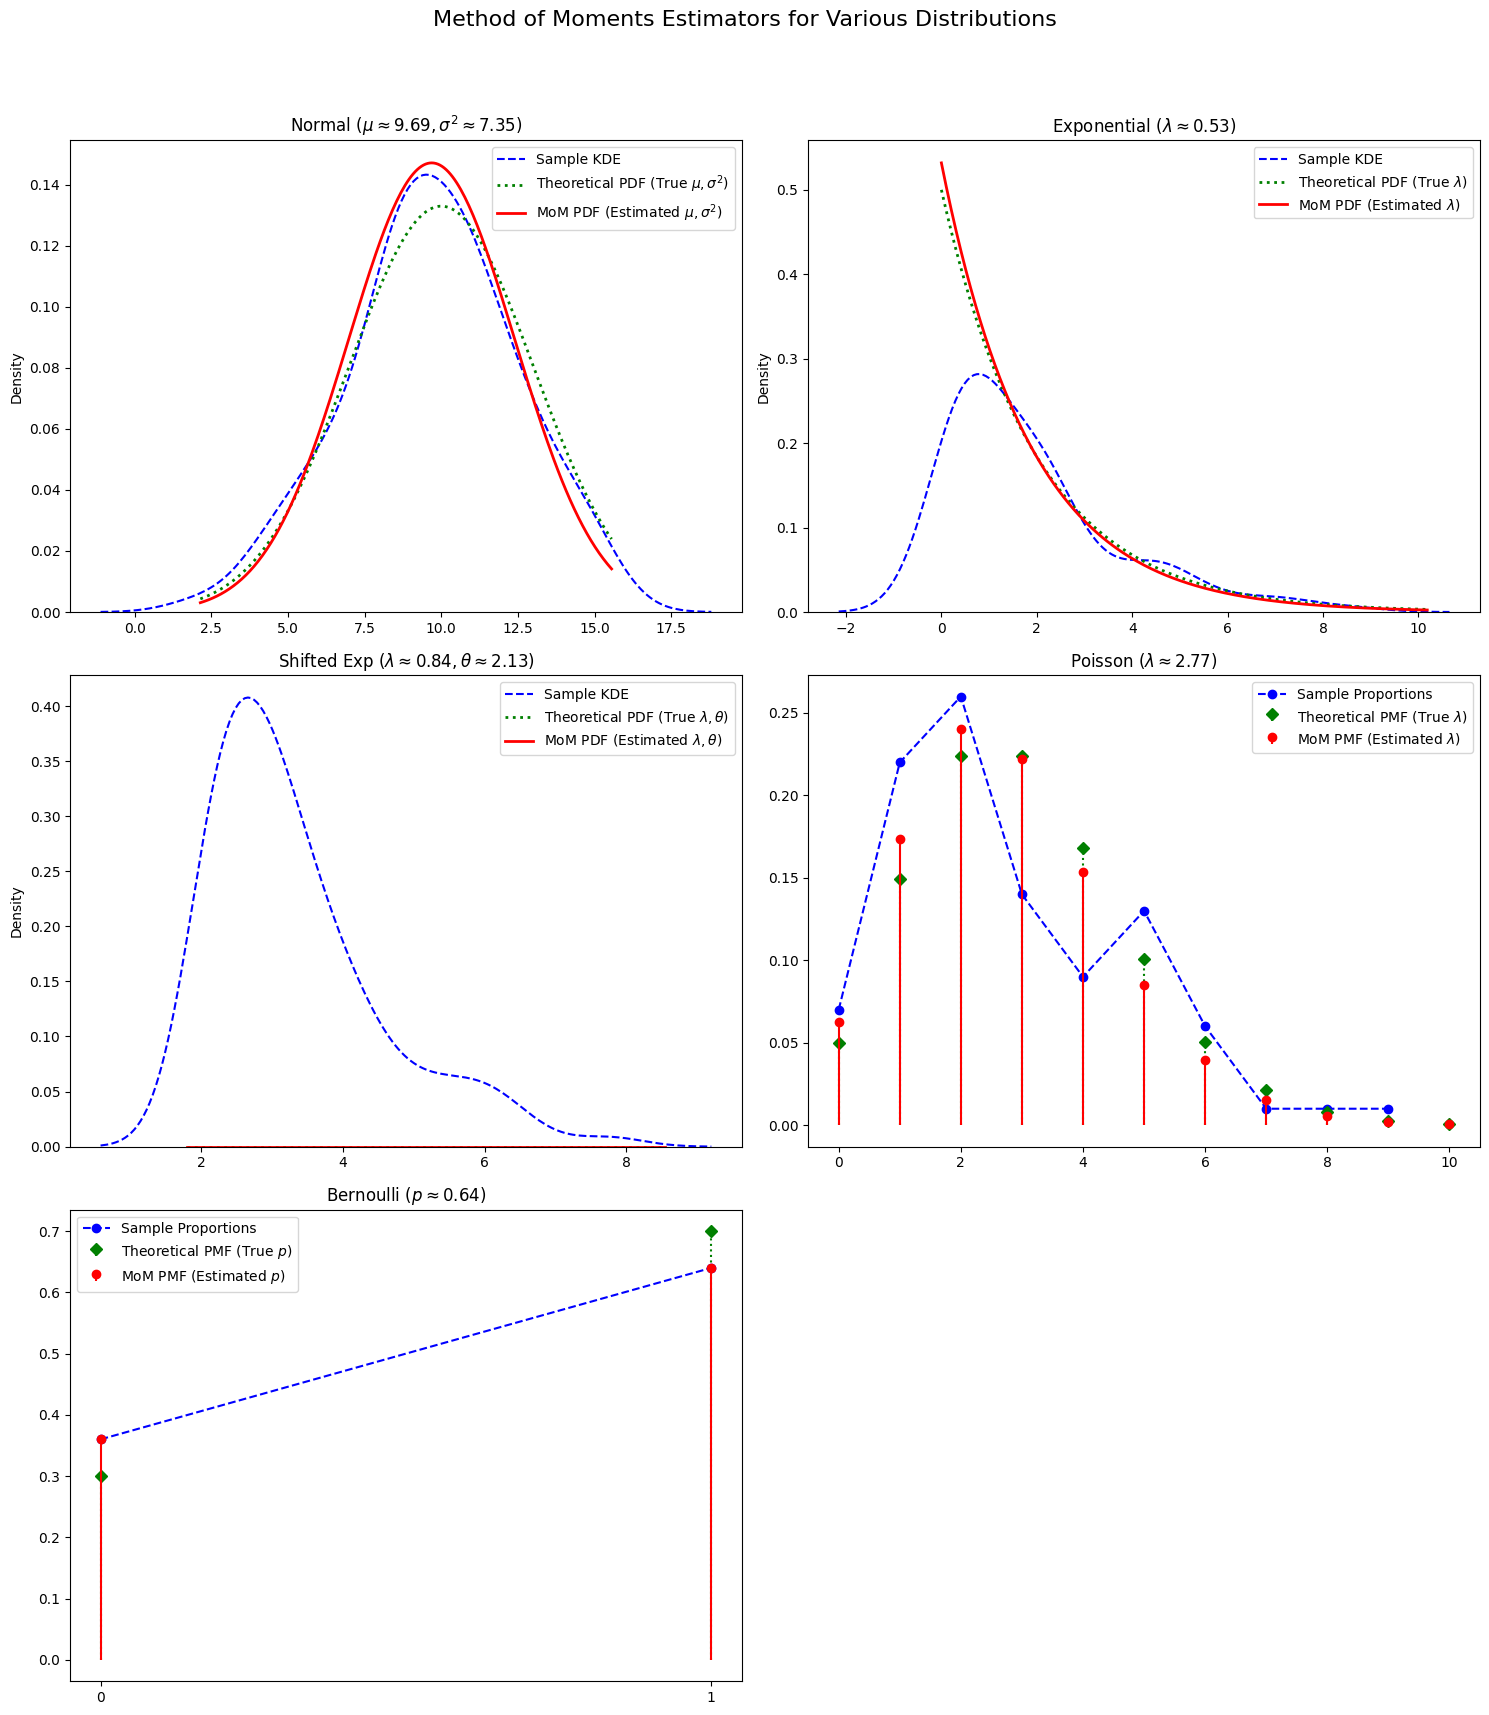

In [12]:
'''  MoM for Normal Distribution, Exponential Distribution, Shifted Exponential Distribution, Poisson Distribution, Bernoulli Distribution '''

### Method of Moments (MoM) vs. Maximum Likelihood Estimation (MLE)

The Method of Moments (MoM) and Maximum Likelihood Estimation (MLE) are two fundamental approaches for estimating parameters of a probability distribution from sample data. While both aim to find good estimators, they differ significantly in their underlying principles, computational complexity, and statistical properties.

### *Method of Moments (MoM)

**Principle:** Equates population moments (e.g., $E[X]$, $E[X^2]$) to corresponding sample moments (e.g., $\bar{X}$, $\frac{1}{n}\sum X_i^2$). If there are $k$ parameters, the first $k$ population moments are equated to the first $k$ sample moments, and the resulting system of equations is solved for the parameters.

**Advantages:**
*   **Simplicity:** Often straightforward to derive and computationally simpler than MLE, especially for distributions where moments can be expressed in closed form. **Less Assumptions:** Requires fewer assumptions about the underlying distribution than MLE (only that the moments exist). **Consistent:** MoM estimators are generally consistent, meaning they converge to the true parameter values as the sample size increases.

**Disadvantages:**
*   **Efficiency:** MoM estimators are generally not as statistically efficient as MLE estimators. This means that for the same sample size, MLE estimators typically have lower variance. **Bias:** Can be biased, especially for small sample sizes. **Sufficiency:** Does not always use all the available information in the sample, meaning they might not be sufficient statistics. **Not Always Unique:** Sometimes, multiple solutions can arise from the moment equations, or no real solution exists.

### Maximum Likelihood Estimation (MLE)

**Principle:** Identifies the parameter values that maximize the likelihood function, which represents the probability of observing the given sample data under a particular set of parameter values. In essence, it finds the parameters that make the observed data most probable.

**Advantages:**
*   **Efficiency:** MLE estimators are asymptotically efficient, meaning they achieve the lowest possible variance among unbiased estimators as the sample size becomes large (they reach the Cramér-Rao lower bound). **Consistency:** MLE estimators are consistent.**Asymptotic Normality:** For large sample sizes, MLE estimators are approximately normally distributed, which allows for easier construction of confidence intervals and hypothesis tests. **Sufficiency:** If a sufficient statistic exists, the MLE will be a function of it, meaning it uses all relevant information in the sample. **Invariance:** If $\hat{\theta}$ is the MLE for $\theta$, then $g(\hat{\theta})$ is the MLE for $g(\theta)$ for any function $g$.

**Disadvantages:**
*   **Computational Complexity:** Often requires optimization techniques (e.g., numerical methods) to find the maximum of the likelihood function, which can be computationally intensive. **Assumptions:** Requires a full specification of the probability distribution for the data, which might not always be known or correctly assumed. **Local Maxima:** The likelihood function might have multiple local maxima, and optimization algorithms can get stuck in a local maximum rather than finding the global one. **Undefined for Small Samples:** For small sample sizes, MLE estimators can be biased, and their asymptotic properties might not hold.

### Summary of Key Differences:

| Feature                   | Method of Moments (MoM)                                   | Maximum Likelihood Estimation (MLE)                        |
| :------------------------ | :-------------------------------------------------------- | :--------------------------------------------------------- |
| **Principle**             | Equate sample moments to population moments               | Maximize the likelihood of observing the sample data       |
| **Computational Ease**    | Generally simpler, often closed-form solutions            | Often requires numerical optimization                      |
| **Statistical Efficiency**| Less efficient (higher variance)                          | Asymptotically efficient (lower variance)                  |
| **Bias**                  | Can be biased                                             | Asymptotically unbiased (can be biased for small samples)  |
| **Distribution Knowledge**| Requires fewer assumptions about the full distribution    | Requires full specification of the distribution            |
| **Usage**                 | Good for initial estimates, or when MLE is too complex    | Preferred for its strong asymptotic properties and efficiency |

In practice, MLE is generally preferred due to its superior asymptotic properties when the underlying distribution is correctly specified. However, MoM remains a valuable tool due to its simplicity and robustness when the distributional assumptions are uncertain or when MLE is computationally prohibitive.

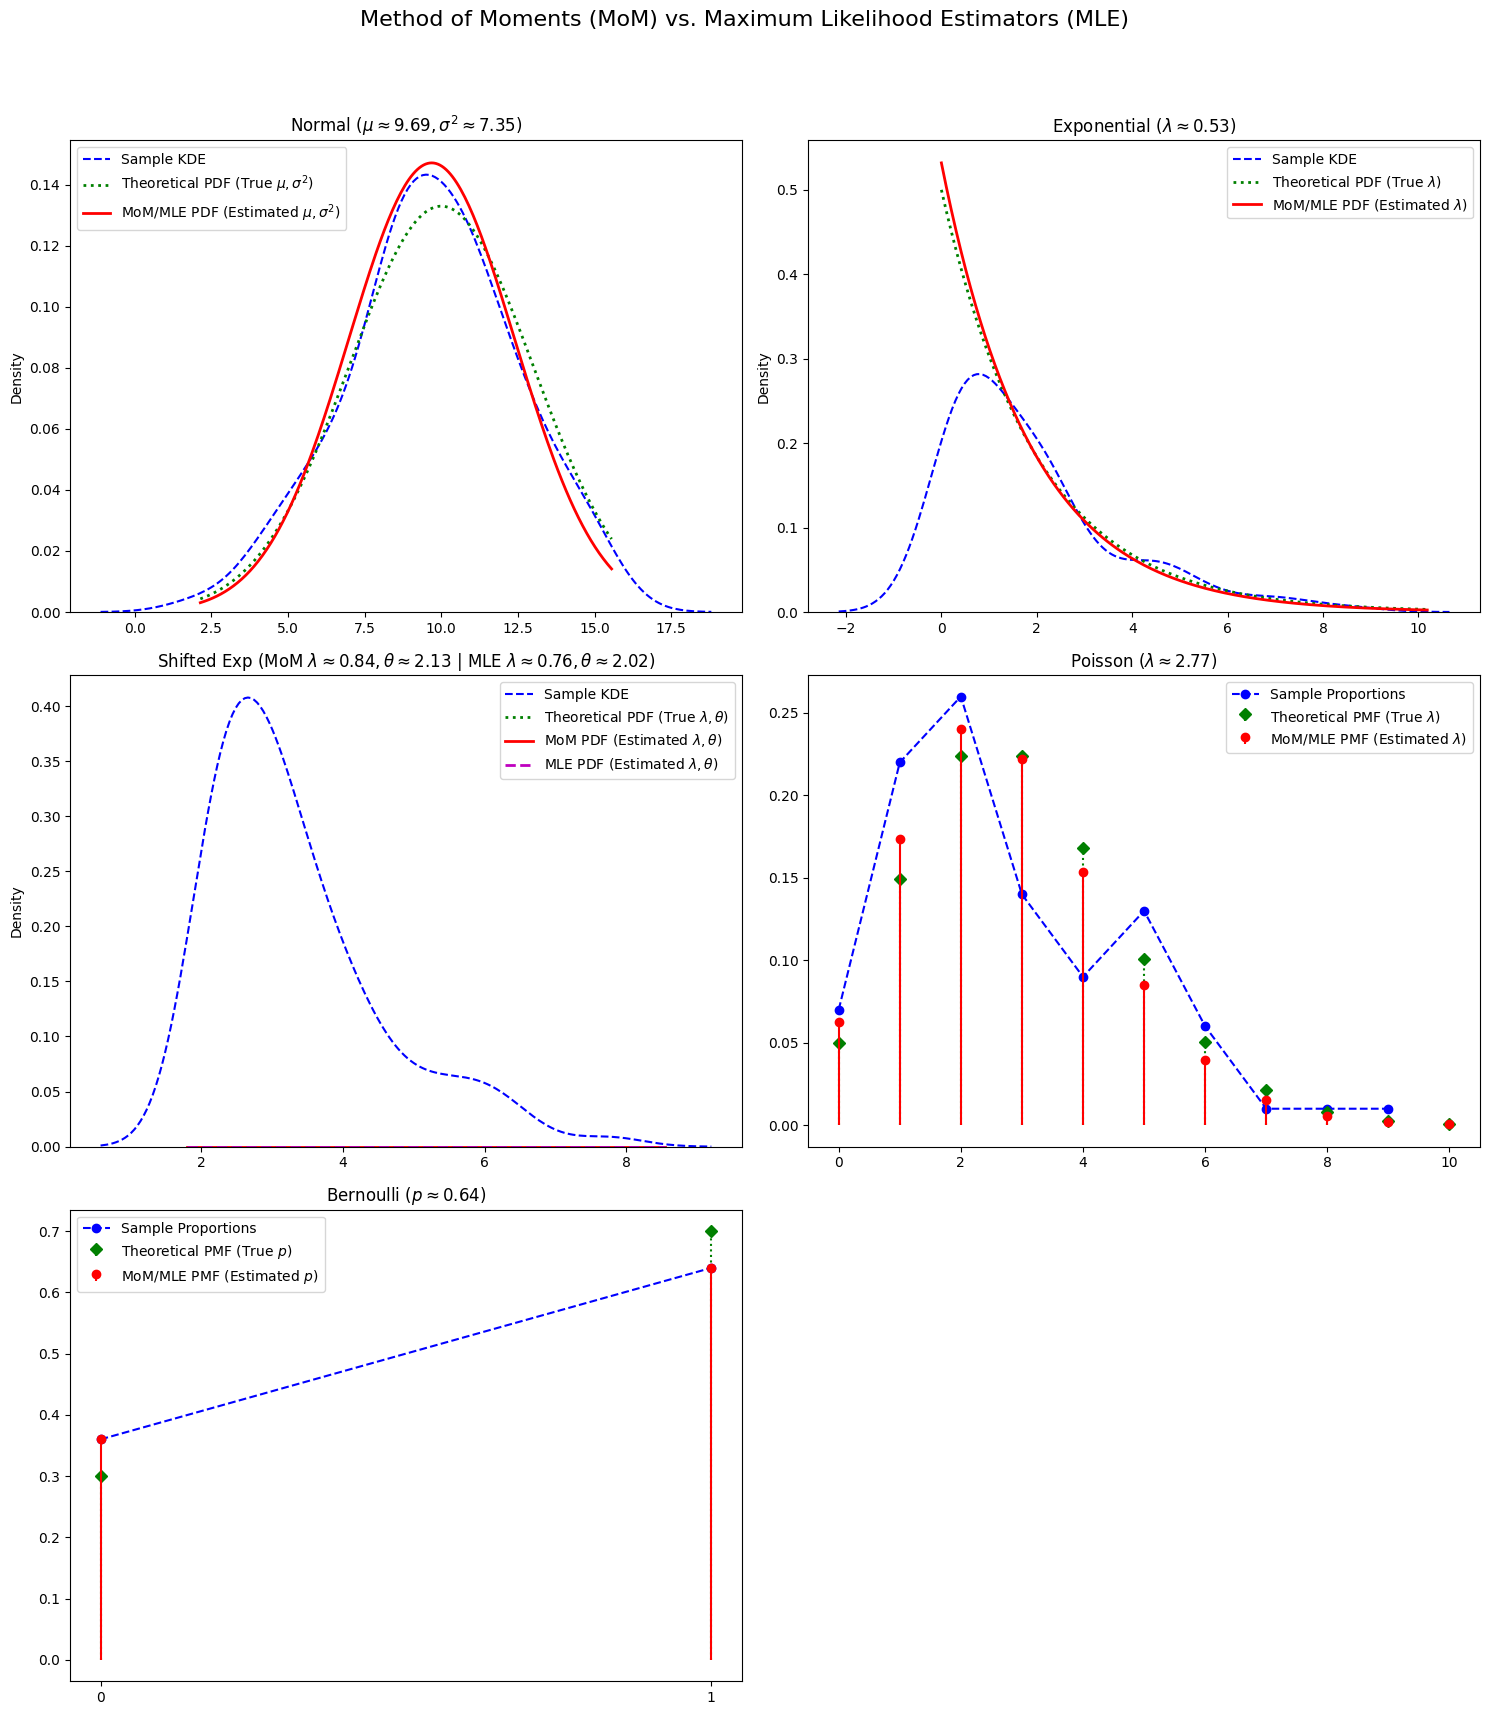

In [16]:
''' MoM and MLE for Normal Distribution, Exponential Distribution, Shifted Exponential Distribution, Poisson Distribution, Bernoulli Distribution '''

#### MLE Derivation for Exponential Distribution

For the **Exponential Distribution** $X \sim Exp(\lambda)$, the probability density function (PDF) is given by $f(x; \lambda) = \lambda e^{-\lambda x}, \quad \text{for } x \ge 0$.

The likelihood function for a sample $X_1, X_2, \dots, X_n$ is $L(\lambda | x_1, \dots, x_n) = \prod_{i=1}^{n} \lambda e^{-\lambda x_i} = \lambda^n e^{-\lambda \sum_{i=1}^{n} x_i}$.

The log-likelihood function is $l(\lambda) = \ln(L(\lambda)) = n \ln(\lambda) - \lambda \sum_{i=1}^{n} x_i$.

To find the MLE for $\lambda$, we take the derivative of the log-likelihood with respect to $\lambda$ and set it to zero $\frac{\partial l}{\partial \lambda} = \frac{n}{\lambda} - \sum_{i=1}^{n} x_i = 0$.
- $\frac{n}{\lambda} = \sum_{i=1}^{n} x_i$
- $\hat{\lambda}_{MLE} = \frac{n}{\sum_{i=1}^{n} x_i} = \frac{1}{\frac{1}{n} \sum_{i=1}^{n} x_i} = \frac{1}{\bar{X}}$

**MLE Estimator for Exponential Distribution**
*   **$\hat{\lambda}_{MLE} = \frac{1}{\bar{X}}$**

As observed, the Maximum Likelihood Estimator for the Exponential distribution is identical to its Method of Moments estimator.

#### MLE Derivation for Shifted Exponential Distribution

For the **Shifted Exponential Distribution** $X \sim Exp(\lambda, \theta)$, the probability density function (PDF) is given by $f(x; \lambda, \theta) = \lambda e^{-\lambda(x - \theta)}, \quad \text{for } x \ge \theta$
The likelihood function for a sample $X_1, X_2, \dots, X_n$ is $L(\lambda, \theta | x_1, \dots, x_n) = \prod_{i=1}^{n} \lambda e^{-\lambda(x_i - \theta)}$.
- $L(\lambda, \theta) = \lambda^n e^{-\lambda \sum_{i=1}^{n} (x_i - \theta)}$

This function is only non-zero if and only if $x_i \ge \theta$ for all $i=1, \dots, n$. This implies that $\theta$ must be less than or equal to the minimum observed value in the sample. To maximize the likelihood function, we need to make $\sum (x_i - \theta)$ as small as possible. This is achieved by making $\theta$ as large as possible, subject to the constraint $x_i \ge \theta$ for all $i$. Therefore, the MLEfor $\theta$ is the minimum value in the sample
- $\hat{\theta}_{MLE} = X_{(1)} = \min(X_1, \dots, X_n)$

Now, substitute $\hat{\theta}_{MLE}$ into the likelihood function and take the natural logarithm to find the log-likelihood for $\lambda$:
- $l(\lambda) = \ln(L(\lambda, \hat{\theta}_{MLE})) = n \ln(\lambda) - \lambda \sum_{i=1}^{n} (x_i - \hat{\theta}_{MLE})$

To find the MLE for $\lambda$, we take the derivative of the log-likelihood with respect to $\lambda$ and set it to zero
- $\frac{\partial l}{\partial \lambda} = \frac{n}{\lambda} - \sum_{i=1}^{n} (x_i - \hat{\theta}_{MLE}) = 0$
- $\frac{n}{\lambda} = \sum_{i=1}^{n} (x_i - \hat{\theta}_{MLE})$
- $\hat{\lambda}_{MLE} = \frac{n}{\sum_{i=1}^{n} (x_i - \hat{\theta}_{MLE})} = \frac{1}{\frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\theta}_{MLE})}$

Recognizing that $\frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\theta}_{MLE})$ is the sample mean of the *shifted* data $(X_i - \hat{\theta}_{MLE})$, we can write
- $\frac{1}{n} \sum_{i=1}^{n} (x_i - \hat{\theta}_{MLE}) = \bar{X} - \hat{\theta}_{MLE}$

Thus, the Maximum Likelihood Estimator for $\lambda$ is $\hat{\lambda}_{MLE} = \frac{1}{\bar{X} - \hat{\theta}_{MLE}}$

MLE Estimators for Shifted Exponential Distribution
- *$\hat{\theta}_{MLE} = \min(X_1, \dots, X_n)$**, **$\hat{\lambda}_{MLE} = \frac{1}{\bar{X} - \hat{\theta}_{MLE}}$**

#### MLE Derivation for Poisson Distribution

For the **Poisson Distribution** $X \sim Pois(\lambda)$, the probability mass function (PMF) is given by $f(x; \lambda) = \frac{\lambda^x e^{-\lambda}}{x!}, \quad \text{for } x = 0, 1, 2, \dots$.

The likelihood function for a sample $X_1, X_2, \dots, X_n$ is $L(\lambda | x_1, \dots, x_n) = \prod_{i=1}^{n} \frac{\lambda^{x_i} e^{-\lambda}}{x_i!} = \frac{\lambda^{\sum x_i} e^{-n\lambda}}{\prod x_i!}$.

The log-likelihood function is $l(\lambda) = \ln(L(\lambda)) = (\sum_{i=1}^{n} x_i) \ln(\lambda) - n\lambda - \ln(\prod_{i=1}^{n} x_i!)$.

To find the MLE for $\lambda$, we take the derivative of the log-likelihood with respect to $\lambda$ and set it to zero
- $\frac{\partial l}{\partial \lambda} = \frac{\sum_{i=1}^{n} x_i}{\lambda} - n = 0$ ;  $\frac{\sum_{i=1}^{n} x_i}{\lambda} = n$
- $\hat{\lambda}_{MLE} = \frac{\sum_{i=1}^{n} x_i}{n} = \bar{X}$

**MLE Estimator for Poisson Distribution**
*   **$\hat{\lambda}_{MLE} = \bar{X}$**

As observed, the Maximum Likelihood Estimator for the Poisson distribution is identical to its Method of Moments estimator.

#### MLE Derivation for Bernoulli Distribution

For the **Bernoulli Distribution** $X \sim Bern(p)$, the probability mass function (PMF) is given by $f(x; p) = p^x (1-p)^{1-x}, \quad \text{for } x \in \{0, 1\}$.

The likelihood function for a sample $X_1, X_2, \dots, X_n$ is $L(p | x_1, \dots, x_n) = \prod_{i=1}^{n} p^{x_i} (1-p)^{1-x_i} = p^{\sum x_i} (1-p)^{n - \sum x_i}$.

Let $k = \sum_{i=1}^{n} x_i$ be the number of successes in $n$ trials. Then the likelihood function is $L(p | x_1, \dots, x_n) = p^k (1-p)^{n-k}$/

The log-likelihood function is $l(p) = \ln(L(p)) = k \ln(p) + (n-k) \ln(1-p)$.

To find the MLE for $p$, we take the derivative of the log-likelihood with respect to $p$ and set it to zero
- $\frac{\partial l}{\partial p} = \frac{k}{p} - \frac{n-k}{1-p} = 0$ ; $\frac{k}{p} = \frac{n-k}{1-p}$ ; $k(1-p) = p(n-k)$ ; $k - kp = np - kp$ ; $k = np$
- $\hat{p}_{MLE} = \frac{k}{n} = \frac{\sum_{i=1}^{n} x_i}{n} = \bar{X}$

**MLE Estimator for Bernoulli Distribution**
*   **$\hat{p}_{MLE} = \bar{X}$**

As observed, the Maximum Likelihood Estimator for the Bernoulli distribution is identical to its Method of Moments estimator.

#### Maximum Likelihood Estimator (MLE) Derivation for Normal Distribution

For the **Normal Distribution** $X \sim N(\mu, \sigma^2)$, the probability density function (PDF) is given by $f(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x - \mu)^2}{2\sigma^2}}$.

The likelihood function for a sample $X_1, X_2, \dots, X_n$ is $L(\mu, \sigma^2 | x_1, \dots, x_n) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x_i - \mu)^2}{2\sigma^2}}$.

The log-likelihood function is $l(\mu, \sigma^2) = \sum_{i=1}^{n} \left( -\frac{1}{2} \ln(2\pi) - \frac{1}{2} \ln(\sigma^2) - \frac{(x_i - \mu)^2}{2\sigma^2} \right)$.
- $l(\mu, \sigma^2) = -\frac{n}{2} \ln(2\pi) - \frac{n}{2} \ln(\sigma^2) - \frac{1}{2\sigma^2} \sum_{i=1}^{n} (x_i - \mu)^2$

To find the MLE for $\mu$, we take the derivative with respect to $\mu$ and set it to zero $\frac{\partial l}{\partial \mu} = -\frac{1}{2\sigma^2} \sum_{i=1}^{n} 2(x_i - \mu)(-1) = 0$ ;$\frac{1}{\sigma^2} \sum_{i=1}^{n} (x_i - \mu) = 0$; $\sum_{i=1}^{n} x_i - n\mu = 0$
- $\hat{\mu}_{MLE} = \frac{1}{n} \sum_{i=1}^{n} x_i = \bar{X}$

To find the MLE for $\sigma^2$, we take the derivative with respect to $\sigma^2$ and set it to zero
- $\frac{\partial l}{\partial \sigma^2} = -\frac{n}{2} \frac{1}{\sigma^2} + \frac{1}{2(\sigma^2)^2} \sum_{i=1}^{n} (x_i - \mu)^2 = 0$ ; $\frac{n}{2\sigma^2} = \frac{1}{2(\sigma^2)^2} \sum_{i=1}^{n} (x_i - \mu)^2$ ; $n\sigma^2 = \sum_{i=1}^{n} (x_i - \mu)^2$.

Substitute $\hat{\mu}_{MLE} = \bar{X}$ into this equation $\hat{\sigma}^2_{MLE} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{X})^2$.

**MLE Estimators for Normal Distribution**
- **$\hat{\mu}_{MLE} = \bar{X}$**, **$\hat{\sigma}^2_{MLE} = \frac{1}{n} \sum_{i=1}^{n} (X_i - \bar{X})^2$**

As observed, the Maximum Likelihood Estimators for the Normal distribution's mean and variance are identical to its Method of Moments estimators.